#Heart Disease Data

Dataset Link: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

##Import library

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import cross_val_score

##Load Dataset

In [180]:
df = pd.read_csv("/content/heart.csv")

##Basic data exploration

In [181]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [183]:
df.shape

(1025, 14)

In [184]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


## Descriptive statistics

In [185]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


##Data cleaning

In [186]:
print(df.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [187]:
print(df.duplicated().sum())

723


In [188]:
df.drop_duplicates(inplace=True)

##Train-Test Split

In [189]:
X = df.drop(columns=['target'], axis=1)
Y = df['target']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=4)
print(X.shape, X_train.shape, X_test.shape)

(302, 13) (241, 13) (61, 13)


##Scaling:

In [190]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

##Naive Bayes vs Decision Tree

Naive Bayes model

In [191]:
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, Y_train)
nb_y_pred = nb_classifier.predict(X_test)

Decision Tree

In [192]:
def tree_depth_tuning(d):
  dt_classifier = DecisionTreeClassifier(max_depth=d,random_state=33)
  dt_classifier.fit(X_train, Y_train)
  y_pred = dt_classifier.predict(X_test)
  accuracy = accuracy_score(Y_test, y_pred)
  return accuracy
tree_result = pd.DataFrame({'D':np.arange(1,10)})
tree_result['accuracy']= tree_result['D'].apply(tree_depth_tuning)
tree_result

,D,accuracy
0,1,0.590164
1,2,0.836066
2,3,0.704918
3,4,0.721311
4,5,0.704918
5,6,0.704918
6,7,0.704918
7,8,0.688525
8,9,0.688525


In [193]:
dt_classifier =  DecisionTreeClassifier(max_depth=2)
dt_classifier.fit(X_train, Y_train)
dt_y_pred = dt_classifier.predict(X_test)

classification report:

In [194]:
print('classification report of Naive Bayes model: ')
print( classification_report(Y_test, nb_y_pred))

classification report of Naive Bayes model: 
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [195]:
print('classification report of Decision Tree: ')
print( classification_report(Y_test, dt_y_pred))

classification report of Decision Tree: 
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        28
           1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



•	Accuracy

In [196]:
print('Accuracy of Naive Bayes-Test: ', accuracy_score(Y_test, nb_y_pred))
print('Accuracy of Decision Tree-Test: ', accuracy_score(Y_test, dt_y_pred))

Accuracy of Naive Bayes-Test:  0.819672131147541
Accuracy of Decision Tree-Test:  0.8360655737704918


•	Precision

In [197]:
print('Precision of Naive Bayes-Test: ', precision_score(Y_test, nb_y_pred))
print('Precision of Decision Tree-Test: ', precision_score(Y_test, dt_y_pred))

Precision of Naive Bayes-Test:  0.8235294117647058
Precision of Decision Tree-Test:  0.8108108108108109


•	Recall

In [198]:
print('Recall of Naive Bayes-Test: ', recall_score(Y_test, nb_y_pred))
print('Recall of Decision Tree-Test: ', recall_score(Y_test, dt_y_pred))

Recall of Naive Bayes-Test:  0.8484848484848485
Recall of Decision Tree-Test:  0.9090909090909091


•	F1-score

In [199]:
print('F1-score of Naive Bayes-Test: ', f1_score(Y_test, nb_y_pred))
print('F1-score of Decision Tree-Test: ', f1_score(Y_test, dt_y_pred))

F1-score of Naive Bayes-Test:  0.835820895522388
F1-score of Decision Tree-Test:  0.8571428571428571


ROC curve - AUC values

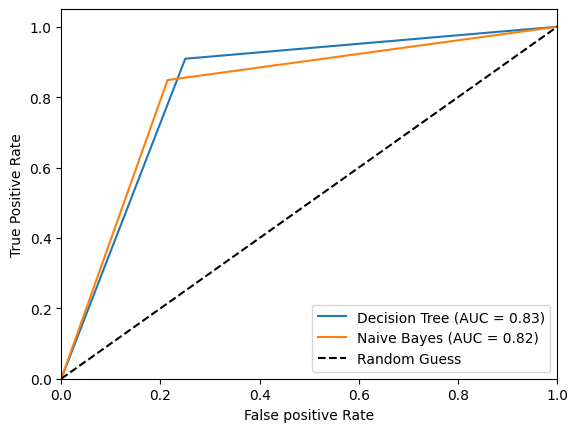

In [200]:
dt_fpr, dt_tpr, thresholds = roc_curve(Y_test, dt_y_pred)
dt_roc_auc = auc(dt_fpr, dt_tpr)

nb_fpr, nb_tpr, nb_thresholds = roc_curve(Y_test, nb_y_pred)
nb_roc_auc = auc(nb_fpr, nb_tpr)

plt.figure()

plt.plot(dt_fpr, dt_tpr, label='Decision Tree (AUC = %0.2f)' % dt_roc_auc)
plt.plot(nb_fpr, nb_tpr, label='Naive Bayes (AUC = %0.2f)' % nb_roc_auc)

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

5-fold cross-validation

In [201]:
dt_Scores = cross_val_score(dt_classifier, X, Y, cv = 5)
nb_Scores = cross_val_score(nb_classifier, X, Y, cv = 5)
print("Decision Tree:")
print(f"Scores for each fold: {dt_Scores} ")
print(f"Mean Accuracy: {dt_Scores.mean():0.2f}")
print("Naive Bayes")
print(f"Scores for each fold: {nb_Scores}")
print(f"Mean Accuracy: {nb_Scores.mean():0.2f}")

Decision Tree:
Scores for each fold: [0.68852459 0.72131148 0.76666667 0.76666667 0.66666667] 
Mean Accuracy: 0.72
Naive Bayes
Scores for each fold: [0.85245902 0.81967213 0.9        0.71666667 0.75      ]
Mean Accuracy: 0.81


##KNN

### KNN Model using Euclidean distance:

####Optimal value of k using Euclidean distance

In [210]:
def knn_tuning(k):
  ed_classifier = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
  ed_classifier.fit(X_train,Y_train)
  ed_y_pred = ed_classifier.predict(X_test)
  accuracy = accuracy_score(Y_test, ed_y_pred)
  return accuracy
knn_result = pd.DataFrame({'K':np.arange(1,30,2)})
knn_result['Accuracy']= knn_result['K'].apply(knn_tuning)
knn_result


,K,Accuracy
0,1,0.770492
1,3,0.770492
2,5,0.852459
3,7,0.836066
4,9,0.836066
5,11,0.786885
6,13,0.770492
7,15,0.754098
8,17,0.770492
9,19,0.770492


####Final Euclidean distance with best K(5)

In [204]:
ed_classifier = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
ed_classifier.fit(X_train,Y_train)
ed_y_pred = ed_classifier.predict(X_test)

In [205]:
print('ed_classifier Accuracy: ', accuracy_score(Y_test, ed_y_pred))

ed_classifier Accuracy:  0.8524590163934426


####Visualize decision boundaries using selected features

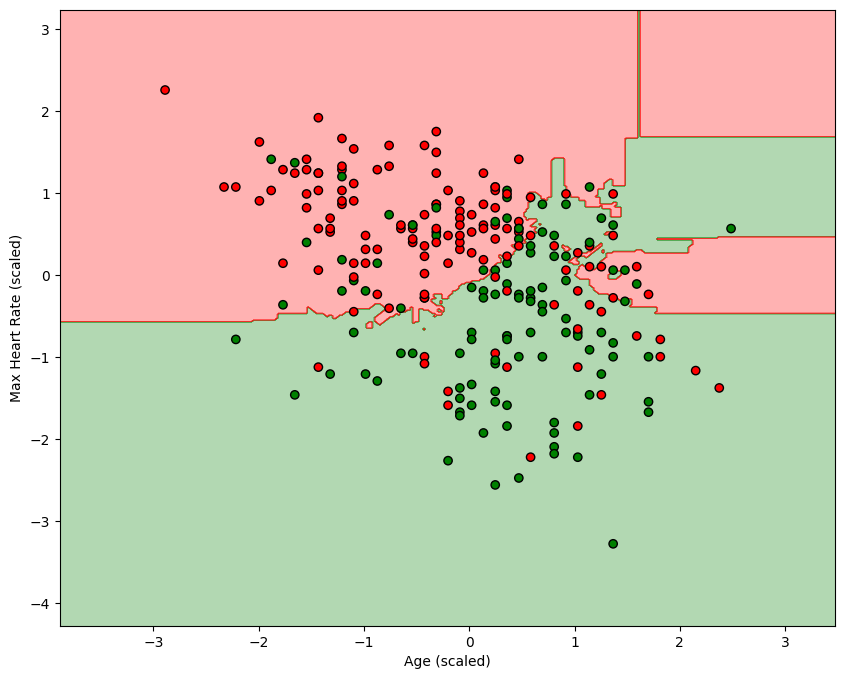

In [208]:
X_visual = X_train.iloc[:,[0,7]].values
y_visual = Y_train.values
visual_classifier = KNeighborsClassifier(n_neighbors=25, metric='manhattan')
visual_classifier.fit(X_visual,y_visual)

h = 0.02
x_min, x_max = X_visual[:,0].min() -1,  X_visual[:,0].max() +1
y_min, y_max =  X_visual[:,1].min() -1,  X_visual[:,1].max() +1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))

visual_predict = visual_classifier.predict(np.c_[xx.ravel(),yy.ravel()])
visual_predict = visual_predict.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, visual_predict, alpha = 0.3, cmap = ListedColormap(('green', 'red')))
plt.scatter(X_visual[:,0], X_visual[:,1], c = y_visual, cmap = ListedColormap(('green', 'red')), edgecolor='k')
plt.xlabel('Age (scaled)')
plt.ylabel('Max Heart Rate (scaled)')
plt.show()


###KNN Model using Manhattan distance:

####Optimal value of k using Manhattan distance:

In [203]:
def knn_tuning(k):
  md_classifier = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
  md_classifier.fit(X_train,Y_train)
  md_y_pred = md_classifier.predict(X_test)
  accuracy = accuracy_score(Y_test, md_y_pred)
  return accuracy
knn_result = pd.DataFrame({'K':np.arange(1,30,2)})
knn_result['Accuracy']= knn_result['K'].apply(knn_tuning)
knn_result


,K,Accuracy
0,1,0.754098
1,3,0.803279
2,5,0.770492
3,7,0.770492
4,9,0.786885
5,11,0.803279
6,13,0.786885
7,15,0.786885
8,17,0.786885
9,19,0.803279


####Final Manhattan distance with best K(25)

In [206]:
md_classifier = KNeighborsClassifier(n_neighbors=25, metric='manhattan')
md_classifier.fit(X_train,Y_train)
md_y_pred = md_classifier.predict(X_test)

In [207]:
print(' md_classifier Accuracy: ', accuracy_score(Y_test, md_y_pred))

 md_classifier Accuracy:  0.819672131147541


####Visualize decision boundaries using selected features.

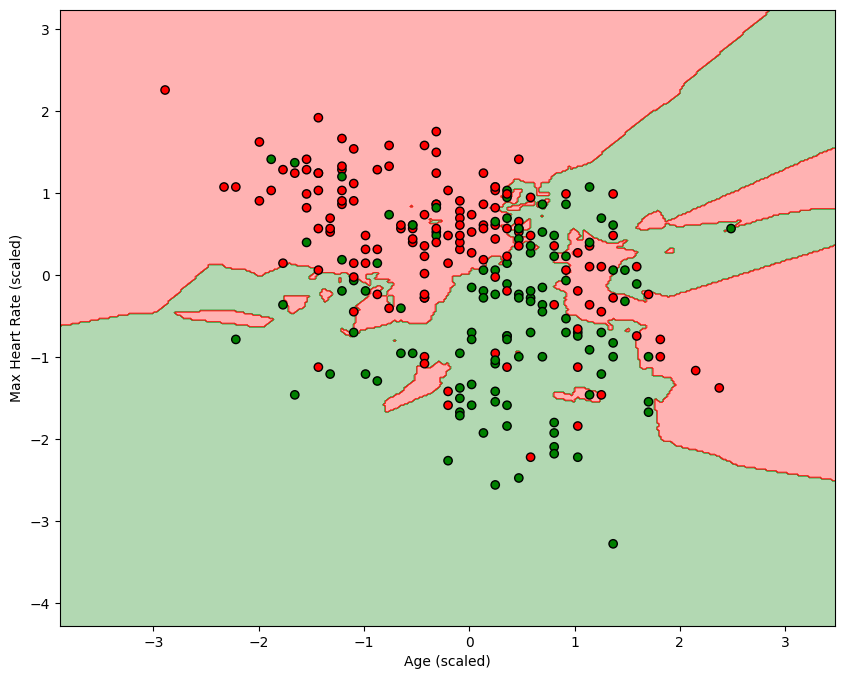

In [209]:
X_visual = X_train.iloc[:,[0,7]].values
y_visual = Y_train.values
visual_classifier = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
visual_classifier.fit(X_visual,y_visual)

h = 0.02
x_min, x_max = X_visual[:,0].min() -1,  X_visual[:,0].max() +1
y_min, y_max =  X_visual[:,1].min() -1,  X_visual[:,1].max() +1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))

visual_predict = visual_classifier.predict(np.c_[xx.ravel(),yy.ravel()])
visual_predict = visual_predict.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, visual_predict, alpha = 0.3, cmap = ListedColormap(('green', 'red')))
plt.scatter(X_visual[:,0], X_visual[:,1], c = y_visual, cmap = ListedColormap(('green', 'red')), edgecolor='k')
plt.xlabel('Age (scaled)')
plt.ylabel('Max Heart Rate (scaled)')
plt.show()